In [1]:
import torch
import nnsight
from sympy.combinatorics import CyclicGroup, DihedralGroup
from src.load_utils import load_gpt, load_task

In [2]:
dirname = '../outputs/mixrosette-facts-10-16-8heads'
gpt = load_gpt(dirname).cuda()
task, task_name = load_task(dirname)
model = nnsight.NNsight(gpt)

number of parameters: 50.42M
iteration: inf
Trained on mixrosette up to order 10 with 16 symbols


#### Train the Closure/Elimination Subspaces

In [ ]:
from src.closure import SubspaceExperimentConfig, run_subspace_optimization_experiment, run_subspace_sweep

# closure subspace
print("Closure Subspace (C Config)")
C_config = SubspaceExperimentConfig(layer=3, component='attn', num_directions=16, constraint_type="C",
                                  allow_identity_facts=False, allow_cf_identity_base_facts=False,
                                  batch_size=2000, num_shots=20, train_batch_size=256, n_steps=250,
                                  eval_interval=2, intervention_index=-1)
C_out = run_subspace_optimization_experiment(model, task, C_config)

# cancellation subspace
print("Cancellation Subspace (LUR Config)")
LUR_config = SubspaceExperimentConfig(layer=3, component='attn', num_directions=16, constraint_type="LUR",
                                  allow_identity_facts=False, allow_cf_identity_base_facts=False,
                                  batch_size=2000, num_shots=20, train_batch_size=256, n_steps=250,
                                  eval_interval=2, intervention_index=-1)
LUR_out = run_subspace_optimization_experiment(model, task, LUR_config)
# torch.save(C_out['subspace'], '../outputs/mixrosette-facts-10-16-8heads/subspaces/closure_subspace_L3_attn_16d.pt')
# torch.save(LUR_out['subspace'], '../outputs/mixrosette-facts-10-16-8heads/subspaces/elimination_subspace_L3_attn_16d.pt')

Closure Subspace (C Config)


Subspace Optimization: 100%|██████████| 251/251 [12:12<00:00,  2.92s/it, Loss=0.0034, Train Acc=1.0000, Val Acc=0.9990, Approx. Mask Sparsity=None]


Cancellation Subspace (LUR Config)


Subspace Optimization: 100%|██████████| 251/251 [11:39<00:00,  2.79s/it, Loss=0.0127, Train Acc=1.0000, Val Acc=0.9950, Approx. Mask Sparsity=None]


In [4]:
# closure subspace w/ identity=True
print("Closure Subspace (C Config + ID)")
C_config_idTRUE = SubspaceExperimentConfig(layer=3, component='attn', num_directions=16, constraint_type="C",
                                  allow_identity_facts=True, allow_cf_identity_base_facts=True,
                                  batch_size=2000, num_shots=20, train_batch_size=256, n_steps=250,
                                  eval_interval=2, intervention_index=-1)
C_out_idTRUE = run_subspace_optimization_experiment(model, task, C_config_idTRUE)

# cancellation subspace w/ identity=True
print("Cancellation Subspace (LUR Config + ID)")
LUR_config_idTRUE = SubspaceExperimentConfig(layer=3, component='attn', num_directions=16, constraint_type="LUR",
                                  allow_identity_facts=True, allow_cf_identity_base_facts=True,
                                  batch_size=2000, num_shots=20, train_batch_size=256, n_steps=250,
                                  eval_interval=2, intervention_index=-1)
LUR_out_idTRUE = run_subspace_optimization_experiment(model, task, LUR_config_idTRUE)

Closure Subspace (C Config + ID)


Subspace Optimization: 100%|██████████| 251/251 [12:14<00:00,  2.93s/it, Loss=0.0242, Train Acc=1.0000, Val Acc=0.9740, Approx. Mask Sparsity=None]


Cancellation Subspace (LUR Config + ID)


Subspace Optimization: 100%|██████████| 251/251 [12:15<00:00,  2.93s/it, Loss=2.3628, Train Acc=0.5411, Val Acc=0.4925, Approx. Mask Sparsity=None]


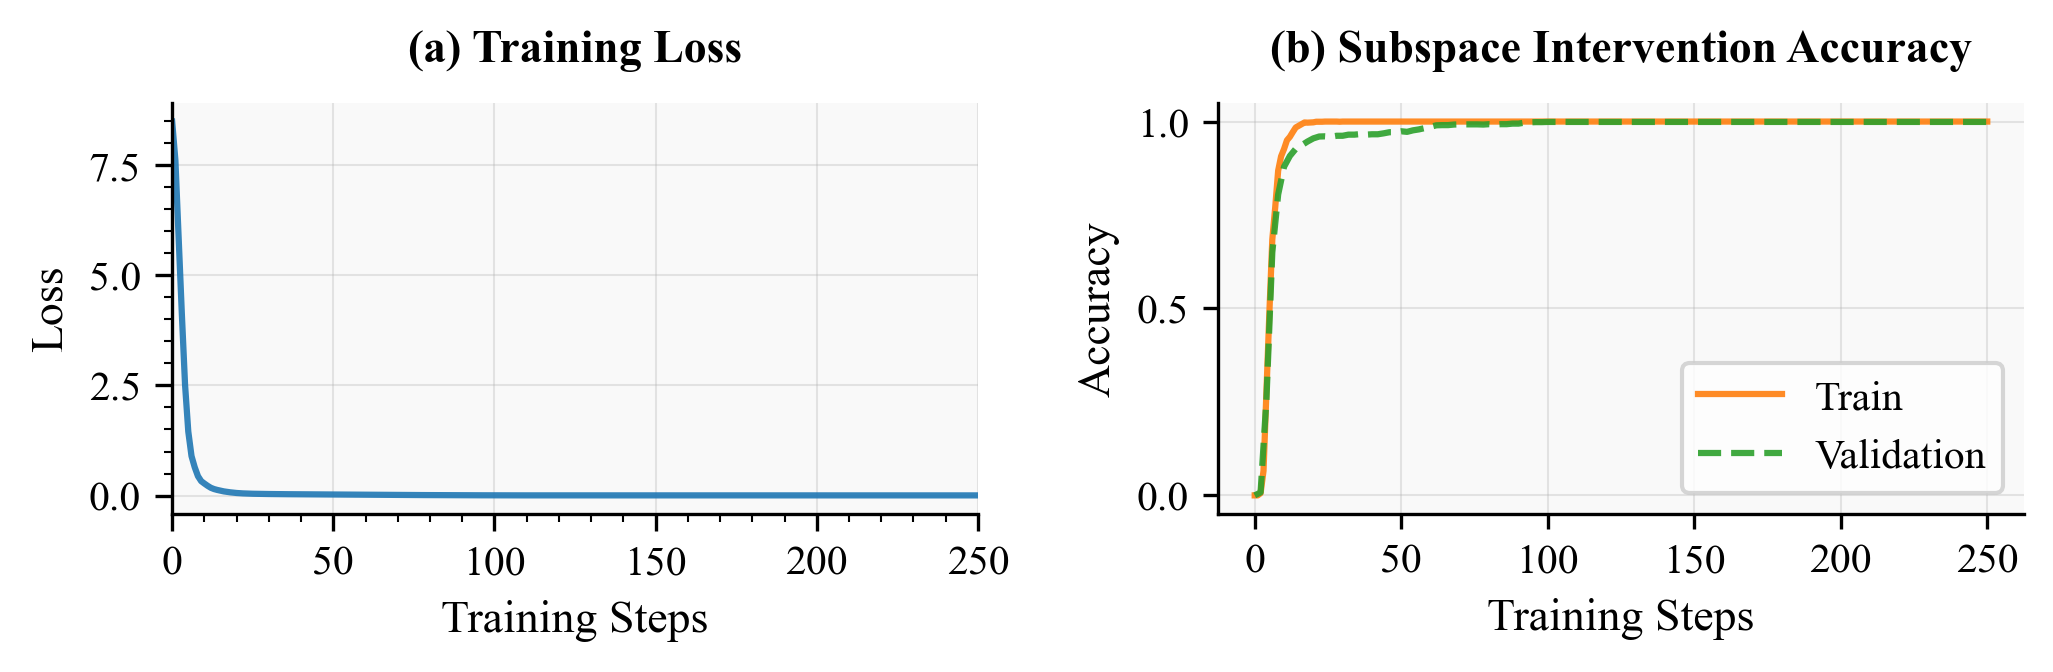

(<Figure size 2100x750 with 2 Axes>,
 array([<Axes: title={'center': '(a) Training Loss'}, xlabel='Training Steps', ylabel='Loss'>,
        <Axes: title={'center': '(b) Subspace Intervention Accuracy'}, xlabel='Training Steps', ylabel='Accuracy'>],
       dtype=object))

In [ ]:
import matplotlib.pyplot as plt

def plot_subspace_results(out, save_path=None):
    """
    Plot training loss and accuracy curves from experiment output.
    
    Args:
        out: Output dict from run_experiment()
        save_path: Optional path to save figure (e.g., 'results.pdf')
    
    Returns:
        fig, axes
    """
    results = out['results']
    config = out['config']
    
    # Set up publication-quality defaults
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['axes.titlesize'] = 11
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['text.usetex'] = False  # Set to True if you have LaTeX installed
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linewidth'] = 0.5
    
    fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
    
    # Colors
    color_loss = '#1f77b4'
    color_train = '#ff7f0e'
    color_val = '#2ca02c'
    
    # Plot 1: Loss
    ax1 = axes[0]
    steps = torch.arange(len(results['losses']))
    ax1.plot(steps, results['losses'], color=color_loss, linewidth=1.5, alpha=0.9)
    ax1.set_xlabel('Training Steps', fontweight='medium')
    ax1.set_ylabel('Loss', fontweight='medium')
    ax1.set_title('(a) Training Loss', fontweight='bold', pad=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlim([0, len(results['losses'])-1])
    ax1.grid(True, alpha=0.3, linewidth=0.5)

    # Add minor ticks
    ax1.minorticks_on()
    ax1.tick_params(which='minor', length=2, width=0.5)
    ax1.tick_params(which='major', length=4, width=0.8)
    
    # Plot 2: Accuracy
    ax2 = axes[1]
    steps_train = torch.arange(len(results['train_accs']))
    steps_val = torch.arange(0, len(results['test_accs']) * config.eval_interval, config.eval_interval)
    
    ax2.plot(steps_train, results['train_accs'], color=color_train, 
             linewidth=1.5, label='Train', alpha=0.9)
    ax2.plot(steps_val, results['test_accs'], color=color_val, 
             linewidth=1.5, label='Validation', alpha=0.9, linestyle='--')
    
    ax2.set_xlabel('Training Steps', fontweight='medium')
    ax2.set_ylabel('Accuracy', fontweight='medium')
    ax2.set_title('(b) Subspace Intervention Accuracy', fontweight='bold', pad=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.legend(loc='lower right', frameon=True)
    ax2.grid(True, alpha=0.3, linewidth=0.5)
    
    for ax in axes:
        ax.set_facecolor('#f9f9f9')
    
    plt.tight_layout(pad=1.5)
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', pad_inches=0.05)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig, axes

plot_subspace_results(C_out)

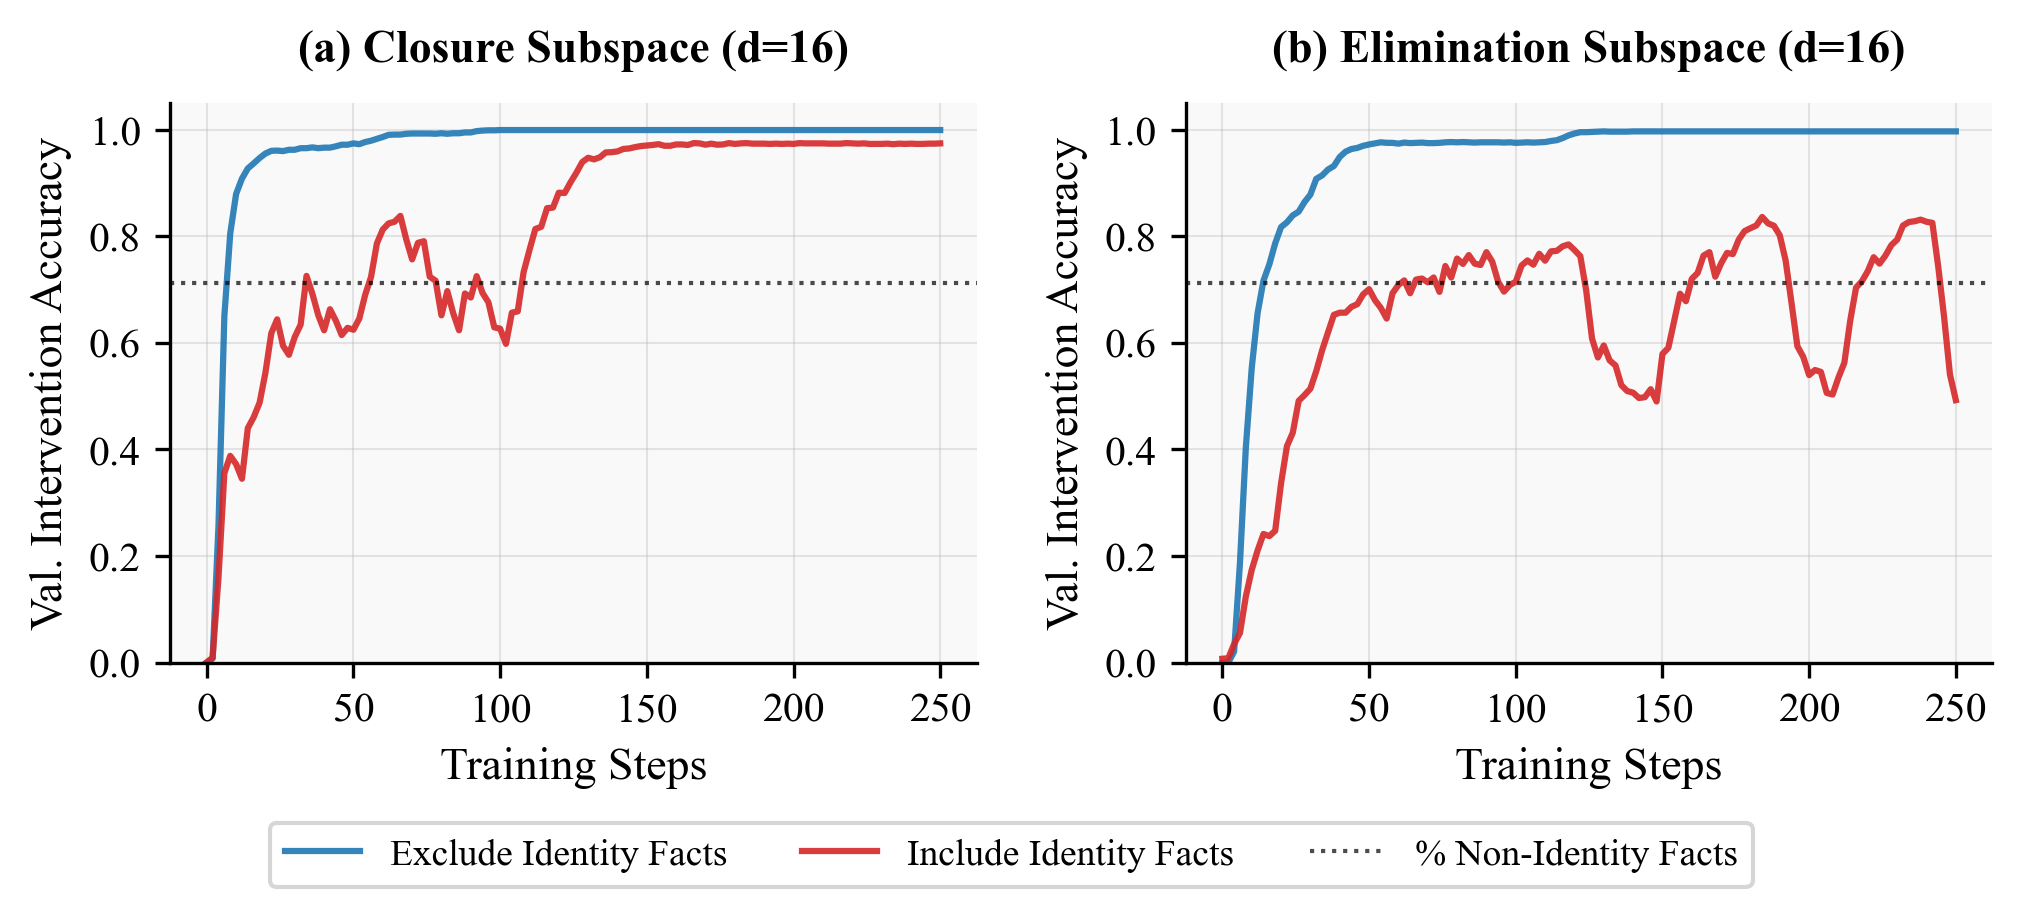

In [ ]:
# Set up publication-quality defaults
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.5

# Colors
colors = {
    'A_val': '#1f77b4',  # blue
    'B_val': '#d62728',  # red
}
labels = {'A': 'Exclude Identity Facts', 'B': 'Include Identity Facts'}

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Data for both plots
plot_data = [
    (C_out_idTRUE, C_out, '(a) Closure Subspace (d=16)'),
    (LUR_out_idTRUE, LUR_out, '(b) Elimination Subspace (d=16)'),
]

for ax, (out, out_alternate, title) in zip(axes, plot_data):
    results = out['results']
    config = out['config']
    results_alt = out_alternate['results']
    config_alt = out_alternate['config']

    steps_val = torch.arange(0, len(results['test_accs']) * config.eval_interval, config.eval_interval)
    steps_val_alt = torch.arange(0, len(results_alt['test_accs']) * config_alt.eval_interval, config_alt.eval_interval)

    
    ax.plot(steps_val_alt, results_alt['test_accs'], color=colors['A_val'], 
            linewidth=1.5, alpha=0.9, label=labels['A'])
    ax.plot(steps_val, results['test_accs'], color=colors['B_val'], 
            linewidth=1.5, alpha=0.9, label=labels['B'])
    
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Training Steps', fontweight='medium')
    ax.set_ylabel('Val. Intervention Accuracy', fontweight='medium')
    ax.set_ylim([0, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_facecolor('#f9f9f9')

# Add horizontal line only for LUR plot
axes[0].axhline(1 - 0.287, color='black', linestyle=':', linewidth=1, alpha=0.7, label='% Non-Identity Facts')
axes[1].axhline(1 - 0.287, color='black', linestyle=':', linewidth=1, alpha=0.7, label='% Non-Identity Facts')


# Get handles and labels from first axis for joint legend
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, frameon=True, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(pad=1.5)
plt.subplots_adjust(bottom=0.22)
# fig.savefig('subspace_training_results.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

#### Sweep Over Closure Subspace Dimension

In [ ]:
from src.closure import SubspaceExperimentConfig, run_subspace_sweep

test_sweep_configs = [
    SubspaceExperimentConfig(layer=L, component='attn', num_directions=D, constraint_type="C",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
dimension_layer_sweep_results = run_subspace_sweep(model, task, test_sweep_configs)

Subspace Optimization: 100%|██████████| 51/51 [02:35<00:00,  3.05s/it, Loss=0.0040, Train Acc=1.0000, Val Acc=0.9995, Approx. Mask Sparsity=None]


In [ ]:
test_sweep_configs_block = [
    SubspaceExperimentConfig(layer=L, component='block', num_directions=D, constraint_type="C",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
dimension_layer_sweep_results_block = run_subspace_sweep(model, task, test_sweep_configs_block)

test_sweep_configs_mlp = [
    SubspaceExperimentConfig(layer=L, component='mlp', num_directions=D, constraint_type="C",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
dimension_layer_sweep_results_mlp = run_subspace_sweep(model, task, test_sweep_configs_mlp)

Subspace Optimization: 100%|██████████| 51/51 [02:25<00:00,  2.86s/it, Loss=3.5316, Train Acc=0.0558, Val Acc=0.0390, Approx. Mask Sparsity=None]


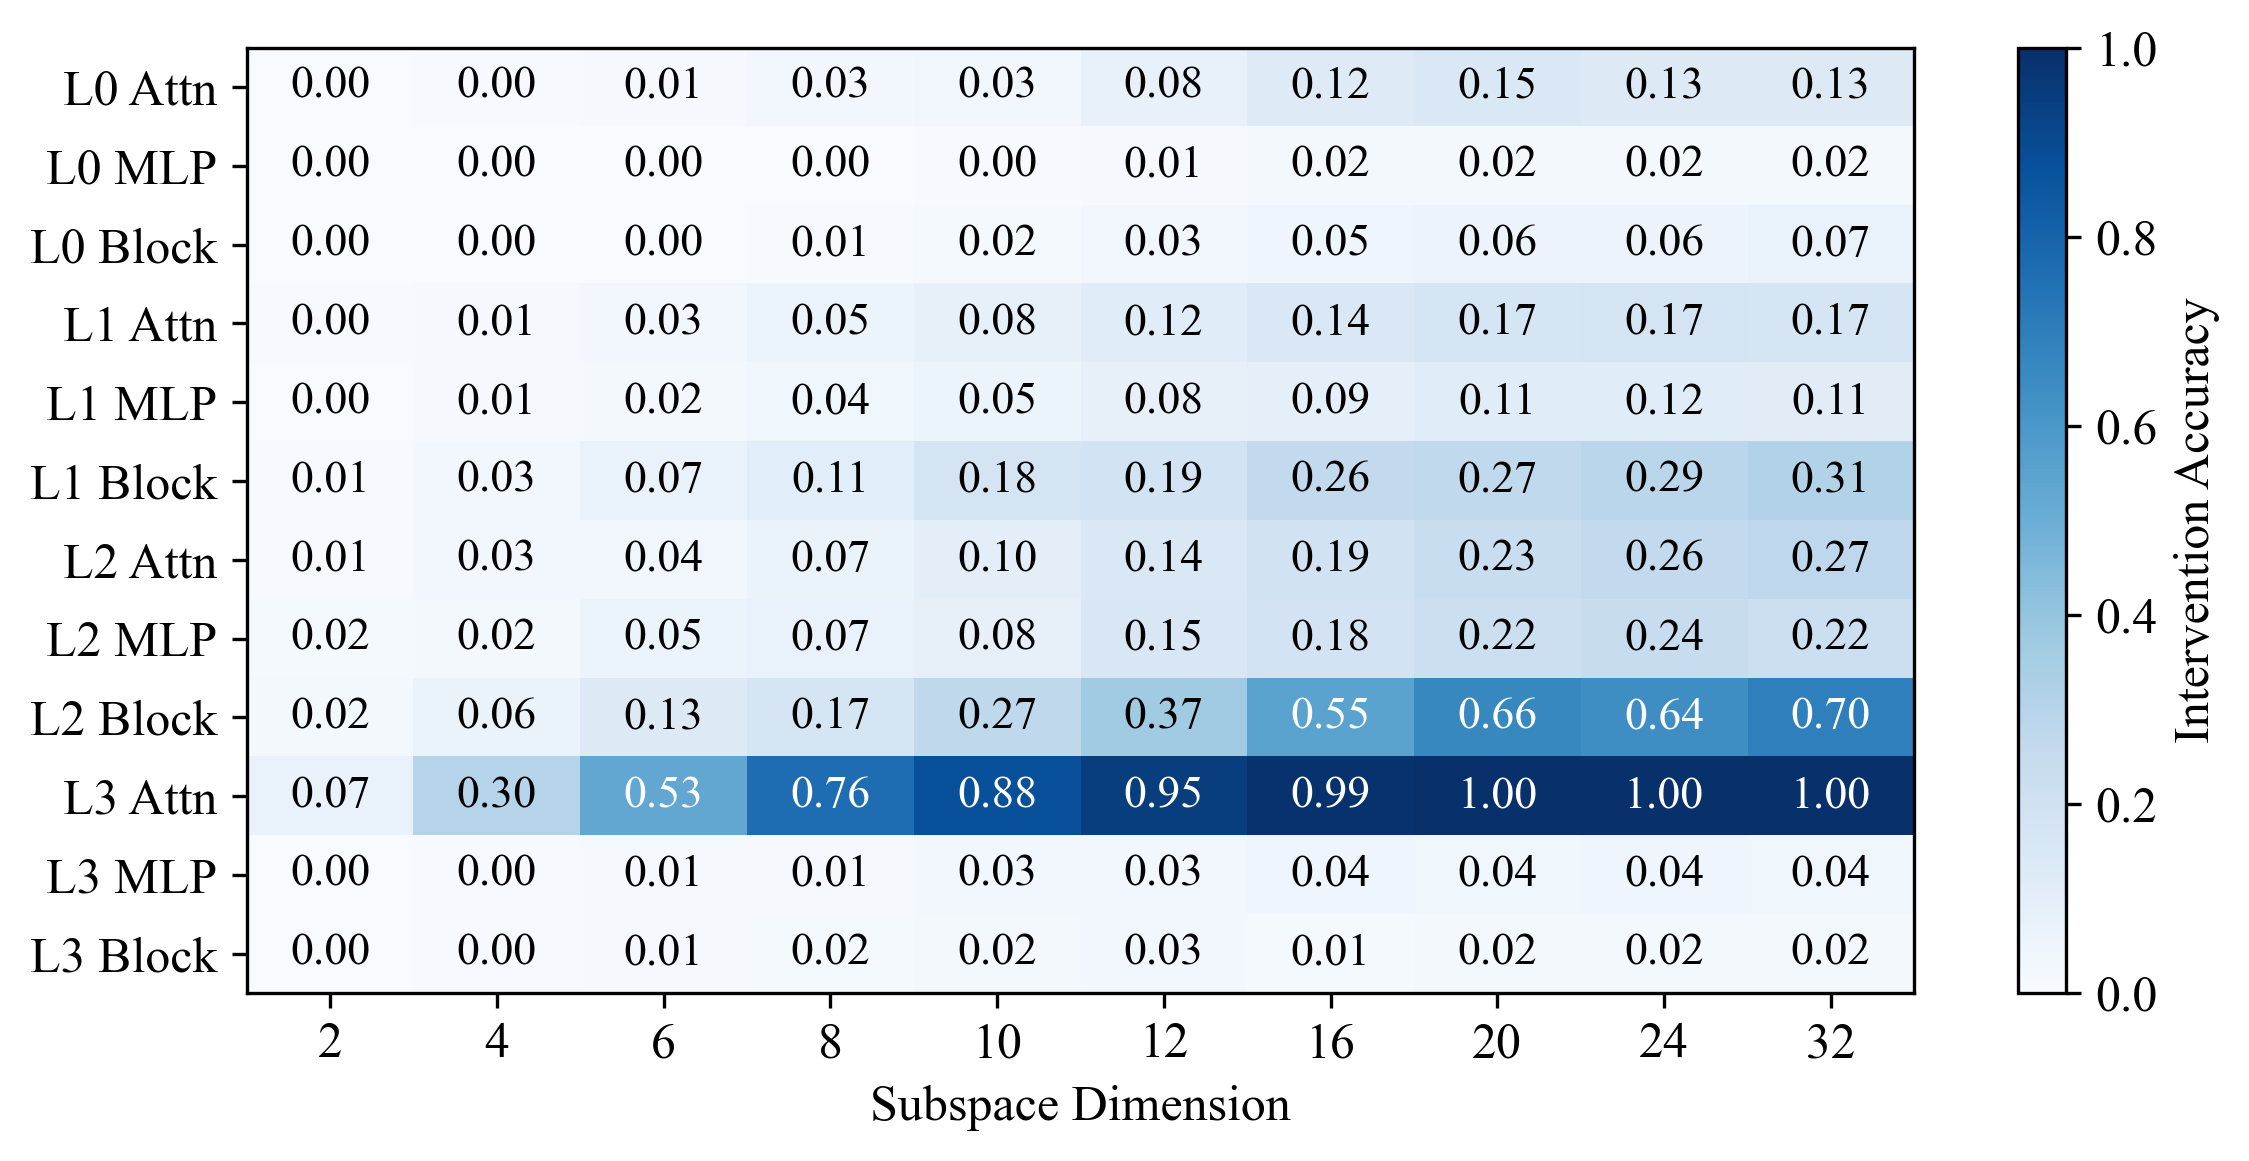

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

A = torch.tensor([out['results']['test_accs'][-1] for out in dimension_layer_sweep_results]).reshape(4,10)
B = torch.tensor([out['results']['test_accs'][-1] for out in dimension_layer_sweep_results_mlp]).reshape(4,10)
C = torch.tensor([out['results']['test_accs'][-1] for out in dimension_layer_sweep_results_block]).reshape(4,10)
data = torch.stack([A, B, C], dim=1).reshape(-1, 10)


im = ax.imshow(data, cmap='Blues', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Intervention Accuracy', fontweight='medium', fontsize=12)
cbar.ax.tick_params(labelsize=12)

# Add text annotations
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        # White text on dark cells, black on light
        color = 'black' if val < 0.5 * (data.max() + data.min()) else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                color=color, fontsize=11)


ax.set_xticks(torch.arange(10), [2,4,6,8,10,12,16,20,24,32], fontsize=12)
ax.set_yticks(torch.arange(12), ['L0 Attn', 'L0 MLP', 'L0 Block', 'L1 Attn', 'L1 MLP', 'L1 Block', 'L2 Attn', 'L2 MLP', 'L2 Block', 'L3 Attn', 'L3 MLP', 'L3 Block'], fontsize=12)

ax.set_xlabel('Subspace Dimension', fontweight='medium', fontsize=12)
# ax.set_ylabel('Attention Layer', fontweight='medium')
# ax.set_title('Validation Accuracy by Configuration', fontweight='bold', pad=10)

ax.grid(False)

plt.tight_layout()
# plt.savefig('closure_subspace_dim_sweep.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

#### Sweep Over Elimination Subspace Location and Dimension

In [4]:
from src.closure import SubspaceExperimentConfig, run_subspace_optimization_experiment, run_subspace_sweep
C_config = SubspaceExperimentConfig(layer=3, component='attn', num_directions=16, constraint_type="C",
                                  allow_identity_facts=False, allow_cf_identity_base_facts=False,
                                  batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                                  eval_interval=2, intervention_index=-1)
C_out = run_subspace_optimization_experiment(model, task, C_config)

Subspace Optimization: 100%|██████████| 51/51 [02:32<00:00,  2.99s/it, Loss=0.0044, Train Acc=1.0000, Val Acc=1.0000, Approx. Mask Sparsity=None]


In [6]:
from src.closure import SubspaceExperimentConfig, run_subspace_sweep

LUR_test_sweep_configs_attn = [
    SubspaceExperimentConfig(layer=L, component='attn', num_directions=D, constraint_type="C",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
LUR_dimension_layer_sweep_results_attn = run_subspace_sweep(model, task, LUR_test_sweep_configs_attn)

LUR_test_sweep_configs_block = [
    SubspaceExperimentConfig(layer=L, component='block', num_directions=D, constraint_type="LUR",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
LUR_dimension_layer_sweep_results_block = run_subspace_sweep(model, task, LUR_test_sweep_configs_block)

LUR_test_sweep_configs_mlp = [
    SubspaceExperimentConfig(layer=L, component='mlp', num_directions=D, constraint_type="LUR",
                             allow_identity_facts=False, allow_cf_identity_base_facts=False,
                             batch_size=2000, num_shots=20, train_batch_size=256, n_steps=50,
                             eval_interval=2, intervention_index=-1)
     for L in [0,1,2,3] for D in [2,4,6,8,10,12,16,20,24,32]
]
LUR_dimension_layer_sweep_results_mlp = run_subspace_sweep(model, task, LUR_test_sweep_configs_mlp)

Subspace Optimization: 100%|██████████| 51/51 [02:24<00:00,  2.83s/it, Loss=2.7328, Train Acc=0.1610, Val Acc=0.1290, Approx. Mask Sparsity=None]


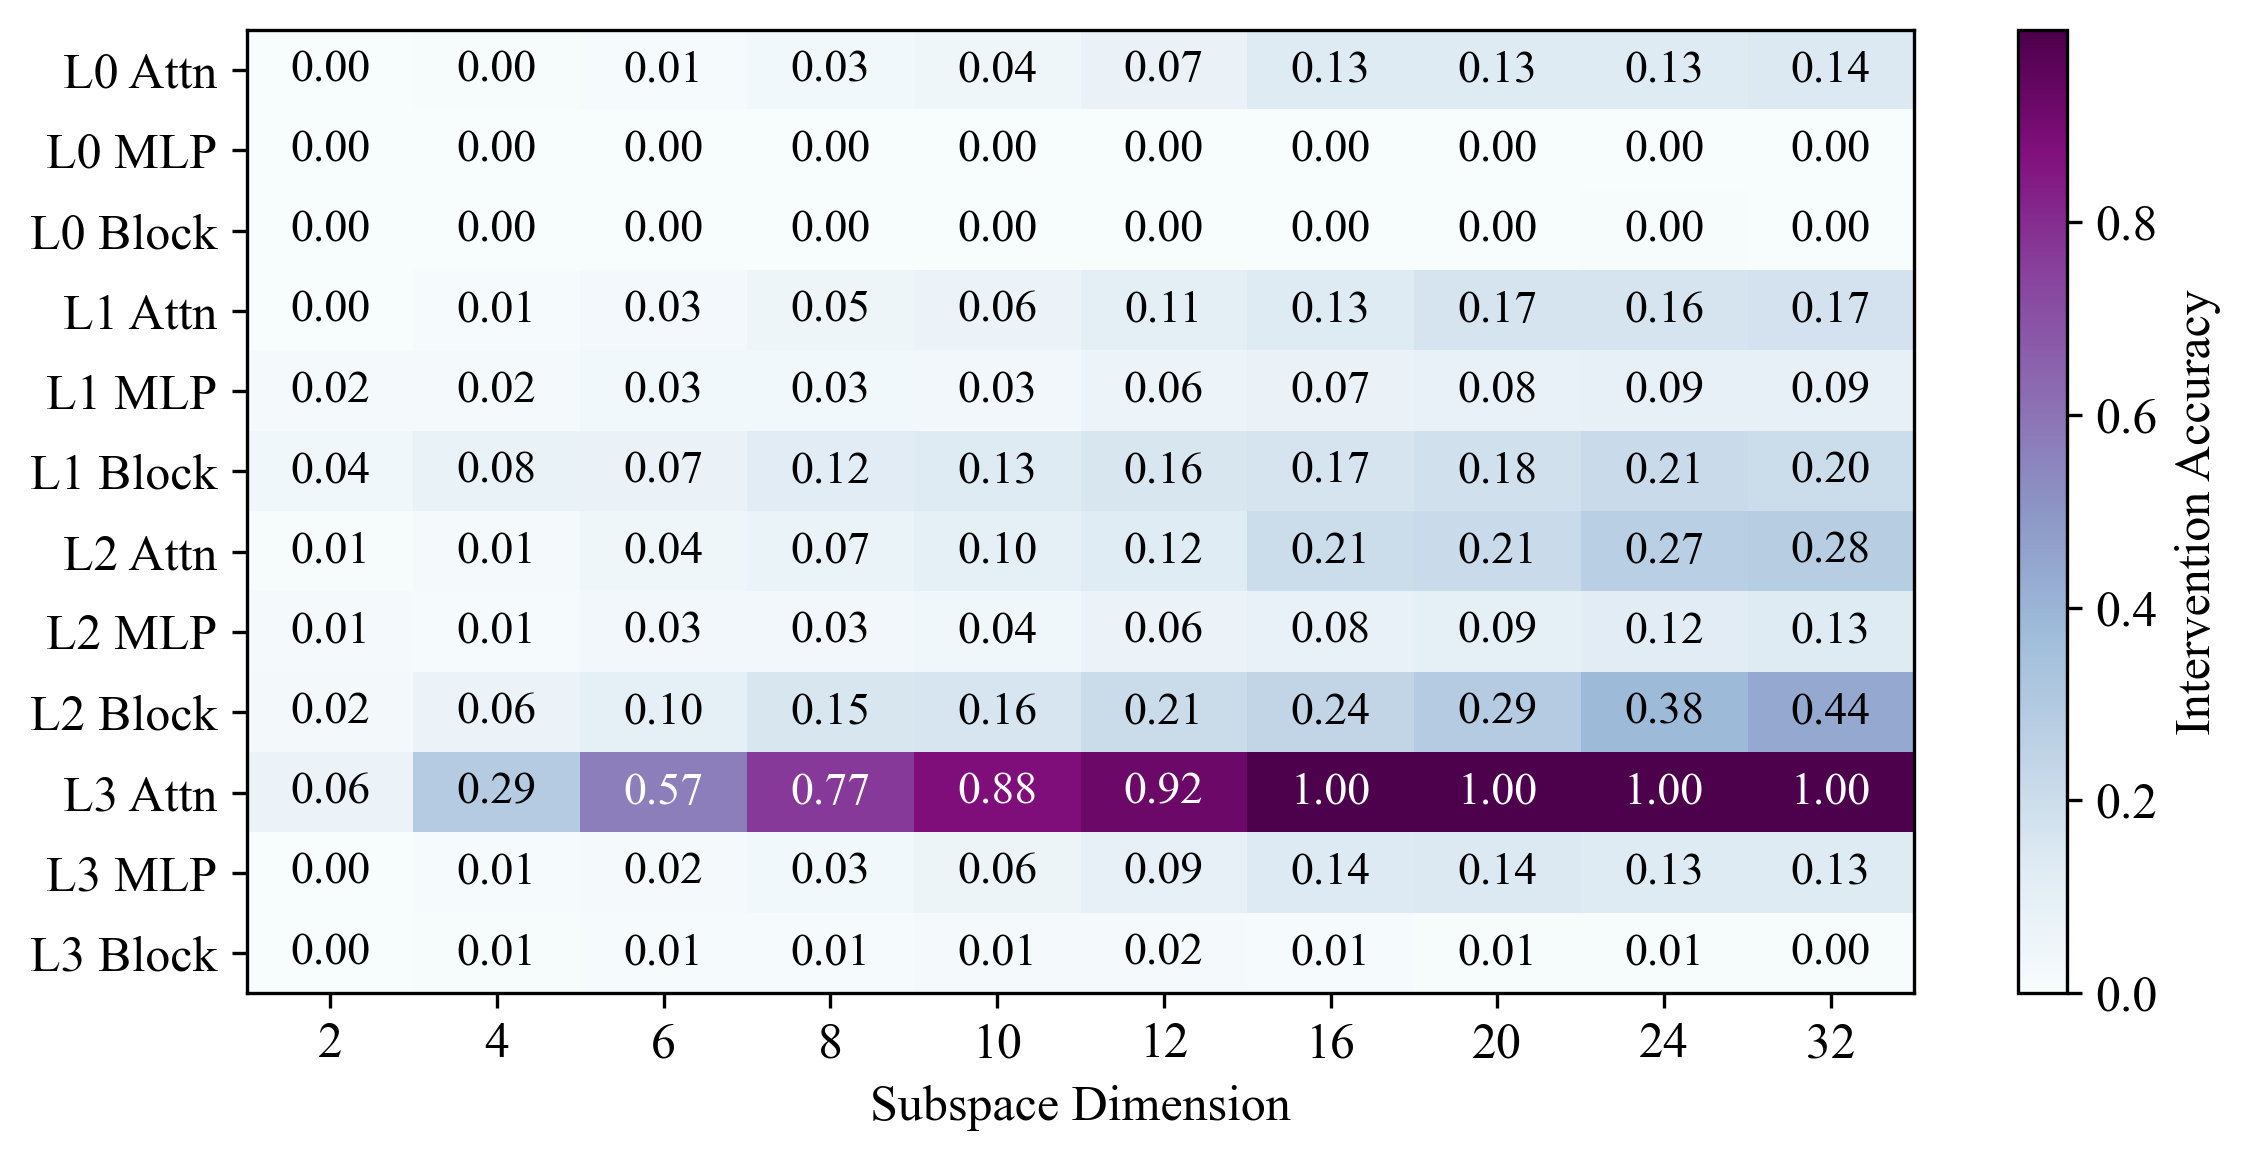

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.5

fig, ax = plt.subplots(figsize=(8, 4))

A = torch.tensor([out['results']['test_accs'][-1] for out in LUR_dimension_layer_sweep_results_attn]).reshape(4,10)
B = torch.tensor([out['results']['test_accs'][-1] for out in LUR_dimension_layer_sweep_results_mlp]).reshape(4,10)
C = torch.tensor([out['results']['test_accs'][-1] for out in LUR_dimension_layer_sweep_results_block]).reshape(4,10)
data = torch.stack([A, B, C], dim=1).reshape(-1, 10)


im = ax.imshow(data, cmap='BuPu', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Intervention Accuracy', fontweight='medium', fontsize=12)
cbar.ax.tick_params(labelsize=12)

# Add text annotations
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        # White text on dark cells, black on light
        color = 'black' if val < 0.5 * (data.max() + data.min()) else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                color=color, fontsize=11)


ax.set_xticks(torch.arange(10), [2,4,6,8,10,12,16,20,24,32], fontsize=12)
ax.set_yticks(torch.arange(12), ['L0 Attn', 'L0 MLP', 'L0 Block', 'L1 Attn', 'L1 MLP', 'L1 Block', 'L2 Attn', 'L2 MLP', 'L2 Block', 'L3 Attn', 'L3 MLP', 'L3 Block'], fontsize=12)

ax.set_xlabel('Subspace Dimension', fontweight='medium', fontsize=12)
# ax.set_ylabel('Attention Layer', fontweight='medium')
# ax.set_title('Validation Accuracy by Configuration', fontweight='bold', pad=10)

ax.grid(False)

plt.tight_layout()
# plt.savefig('elimination_subspace_dim_sweep.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

#### Subspace Probes

In [ ]:
import torch
import matplotlib.pyplot as plt
from src.subspace_probing import *

# =============================================================================
# Setup
# =============================================================================

layer = 3
component = 'attn'
vocab_symbols = task.vocab[:16]

# Load trained subspaces
closure_subspace = torch.load('../outputs/mixrosette-facts-10-16-8heads/subspaces/closure_subspace_L3_attn_16d.pt', weights_only=True)
elimination_subspace = torch.load('../outputs/mixrosette-facts-10-16-8heads/subspaces/elimination_subspace_L3_attn_16d.pt', weights_only=True)

# =============================================================================
# Train Probes on Closure Subspace
# =============================================================================

print("Training probes on closure subspace...")
closure_probe_results = train_probes_for_vocabulary(
    model=model,
    task=task,
    subspace_proj=closure_subspace,
    vocab_symbols=vocab_symbols,
    layer=layer,
    component=component,
    batch_size=2000,
    num_shots=20,
    probe_epochs=2000,
    probe_type='closure'
)

# Save results
# torch.save(closure_probe_results, 'probe_results/closure_probes.pt')

# =============================================================================
# Train Probes on Elimination Subspace
# =============================================================================

print("\nTraining probes on elimination subspace...")
elimination_probe_results = train_probes_for_vocabulary(
    model=model,
    task=task,
    subspace_proj=elimination_subspace,
    vocab_symbols=vocab_symbols,
    layer=layer,
    component=component,
    batch_size=2000,
    num_shots=20,
    probe_epochs=2000,
    probe_type='elimination'
)

# Save results
# torch.save(elimination_probe_results, 'probe_results/elimination_probes.pt')

Training probes on closure subspace...


Training probes: 100%|██████████| 16/16 [02:08<00:00,  8.03s/it]



Training probes on elimination subspace...


Training probes: 100%|██████████| 16/16 [02:18<00:00,  8.63s/it]


In [4]:
# =============================================================================
# Evaluate Generalization (generates the matrices)
# =============================================================================

print("\nEvaluating closure probe generalization...")
closure_gen_matrix = evaluate_probe_generalization(
    model=model,
    task=task,
    subspace_proj=closure_subspace,
    probe_results=closure_probe_results,
    vocab_symbols=vocab_symbols,
    layer=layer,
    component=component,
    batch_size=2000,
    num_shots=30,
    probe_type='closure'
)

print("Evaluating elimination probe generalization...")
elimination_gen_matrix = evaluate_probe_generalization(
    model=model,
    task=task,
    subspace_proj=elimination_subspace,
    probe_results=elimination_probe_results,
    vocab_symbols=vocab_symbols,
    layer=layer,
    component=component,
    batch_size=2000,
    num_shots=30,
    probe_type='elimination'
)


Evaluating closure probe generalization...


Evaluating generalization: 100%|██████████| 16/16 [01:52<00:00,  7.00s/it]


Evaluating elimination probe generalization...


Evaluating generalization: 100%|██████████| 16/16 [02:00<00:00,  7.54s/it]



GENERATING PUBLICATION-READY PLOTS

1. Plotting probe generalization comparison...


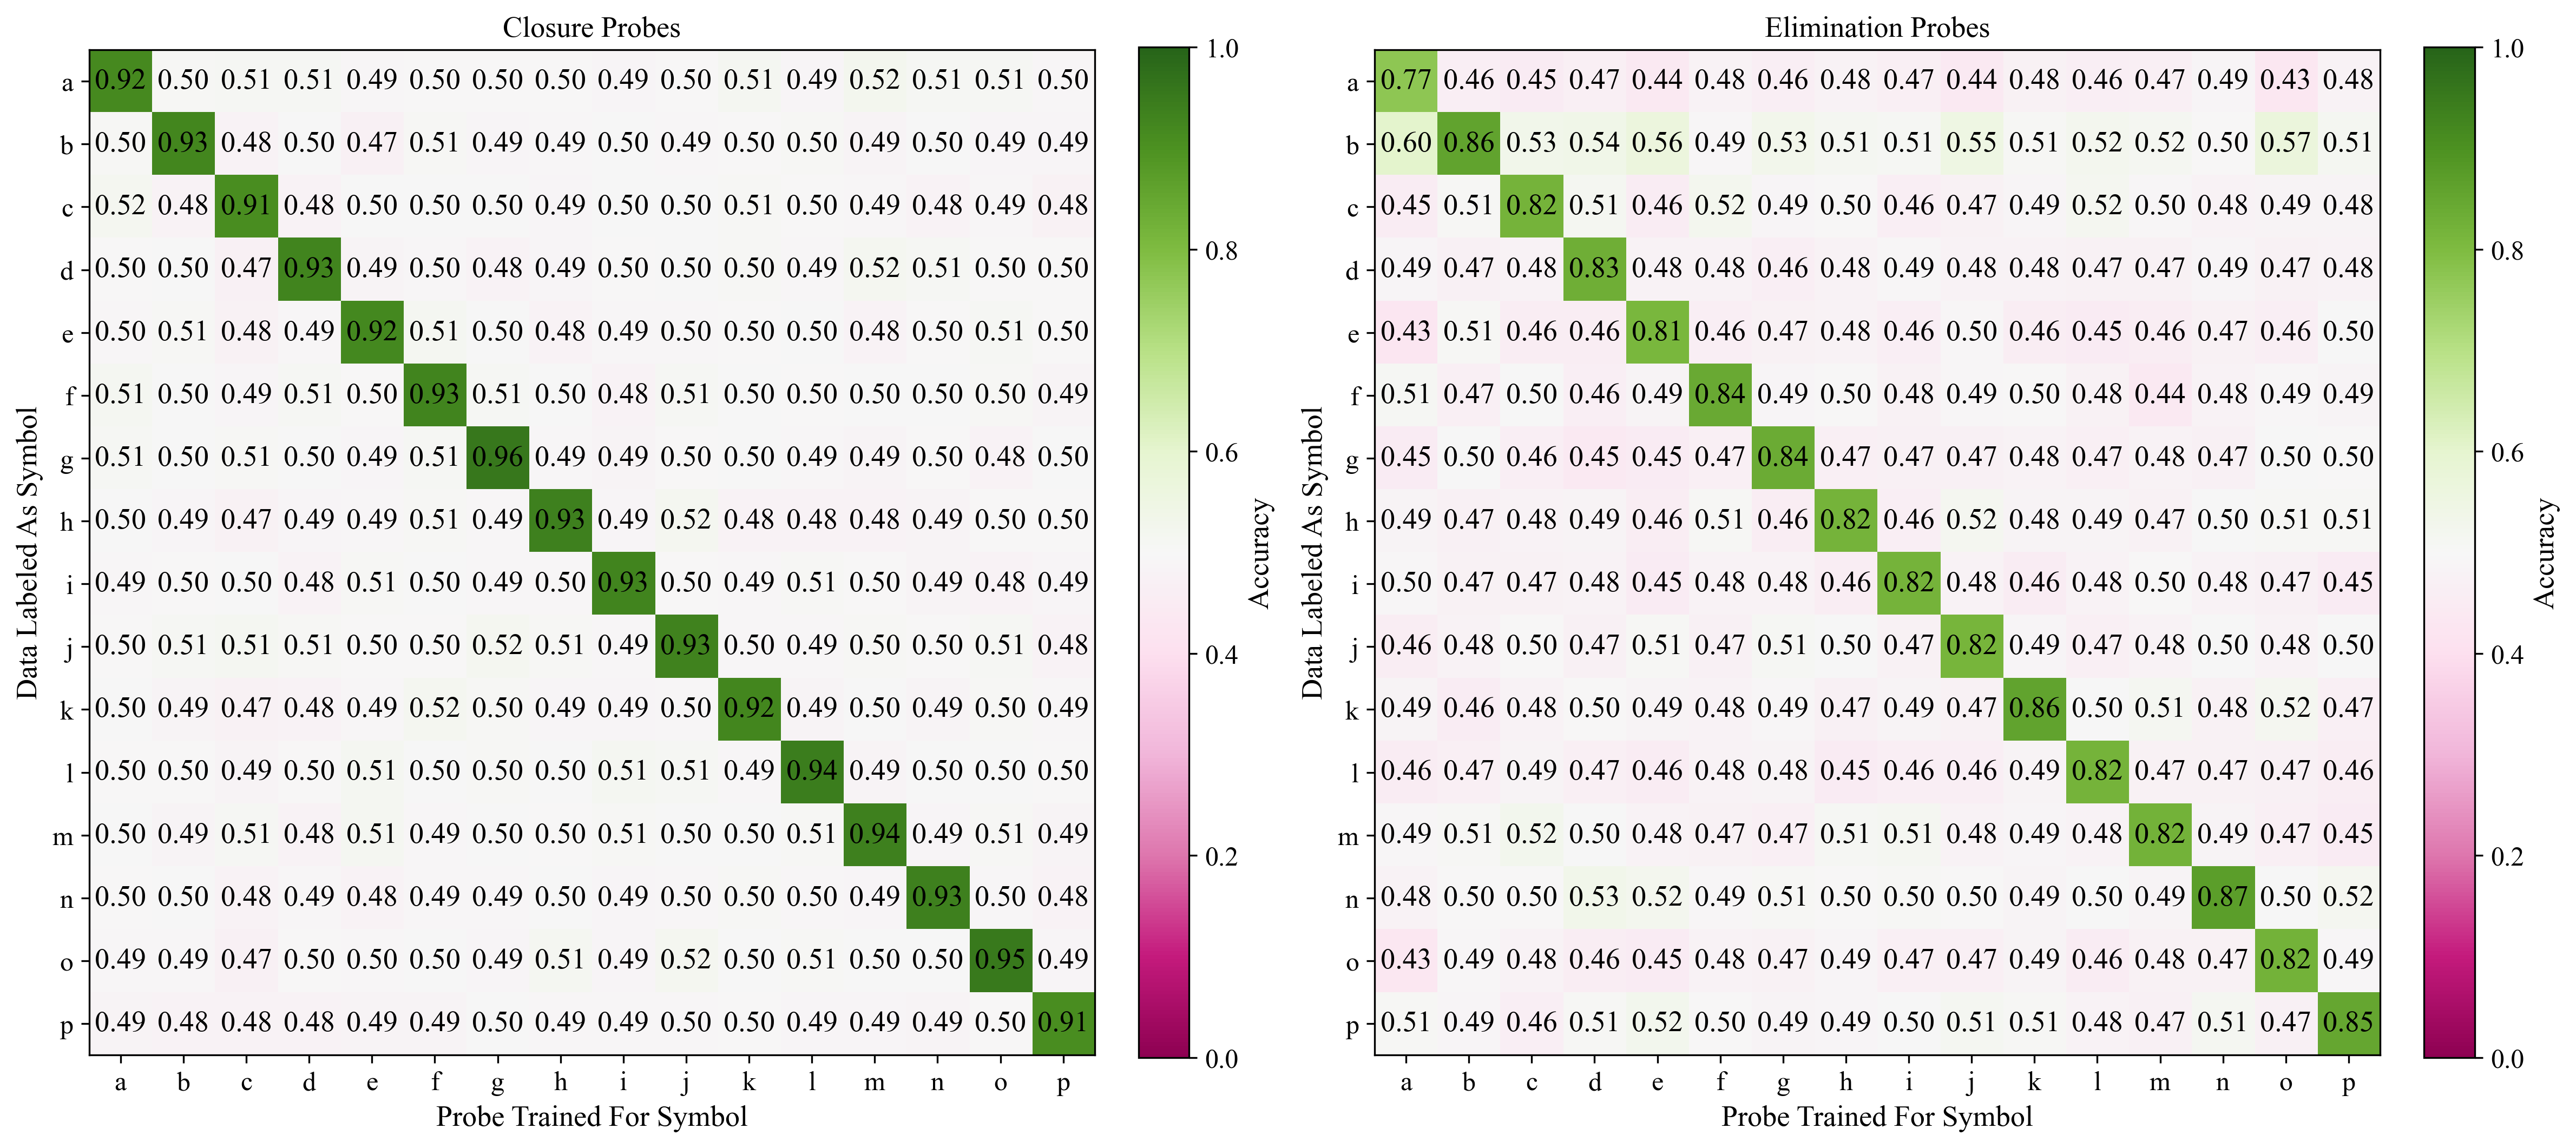

2. Plotting probe-unembed alignment comparison...


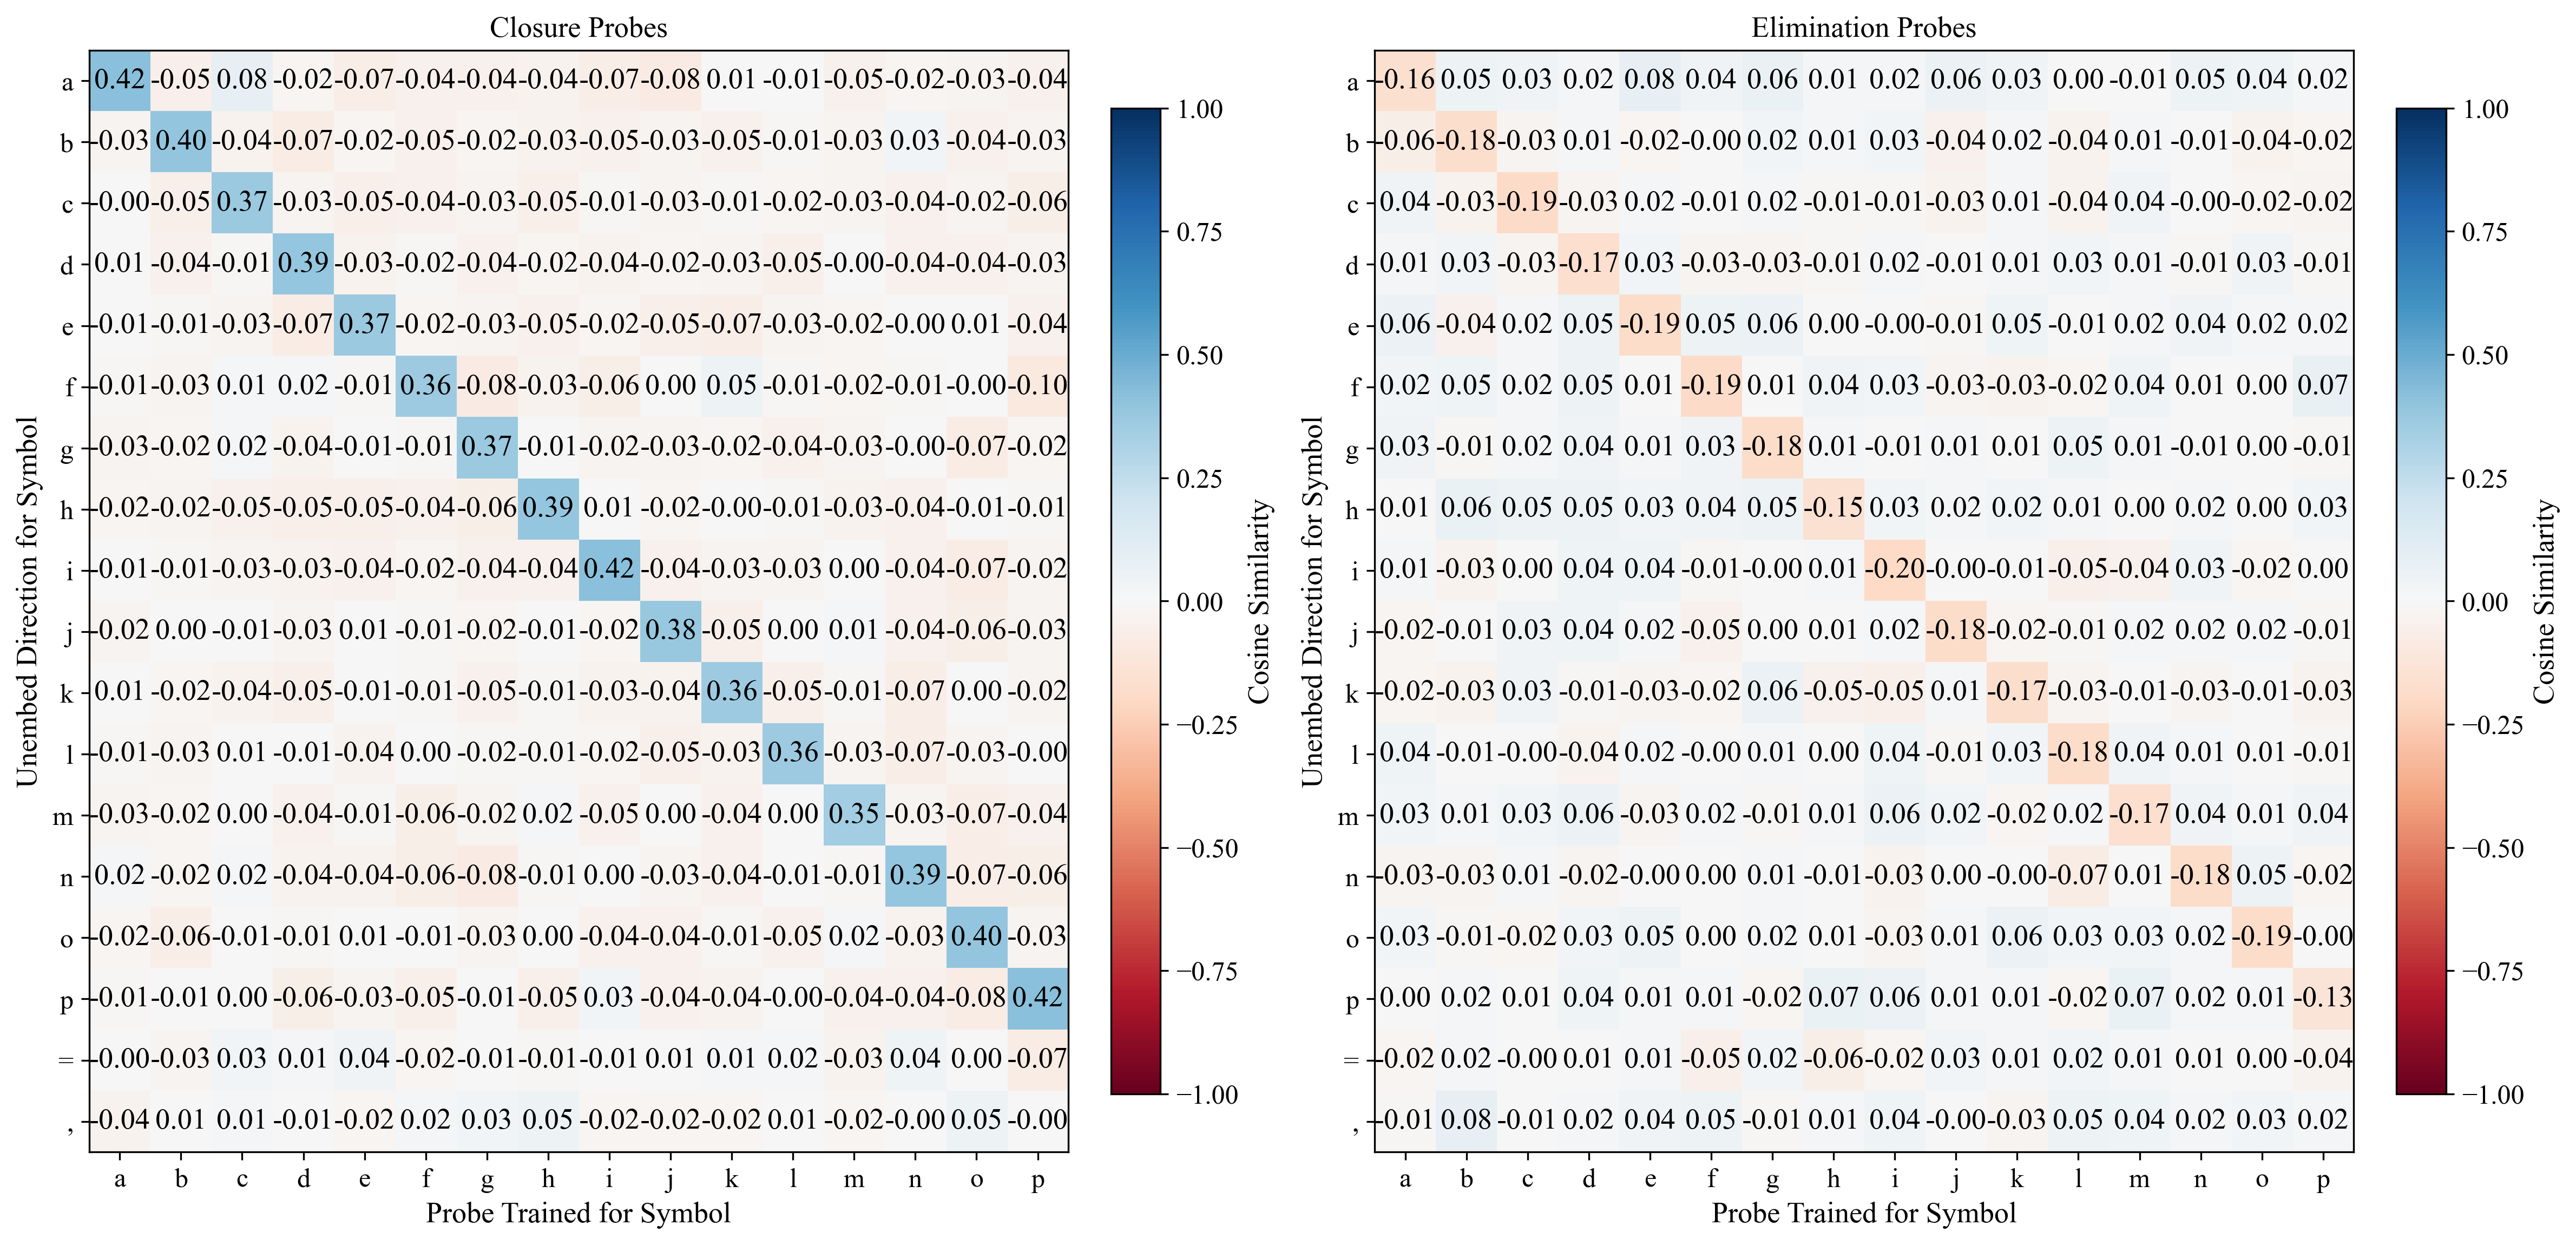

3. Plotting probe direction similarities comparison...


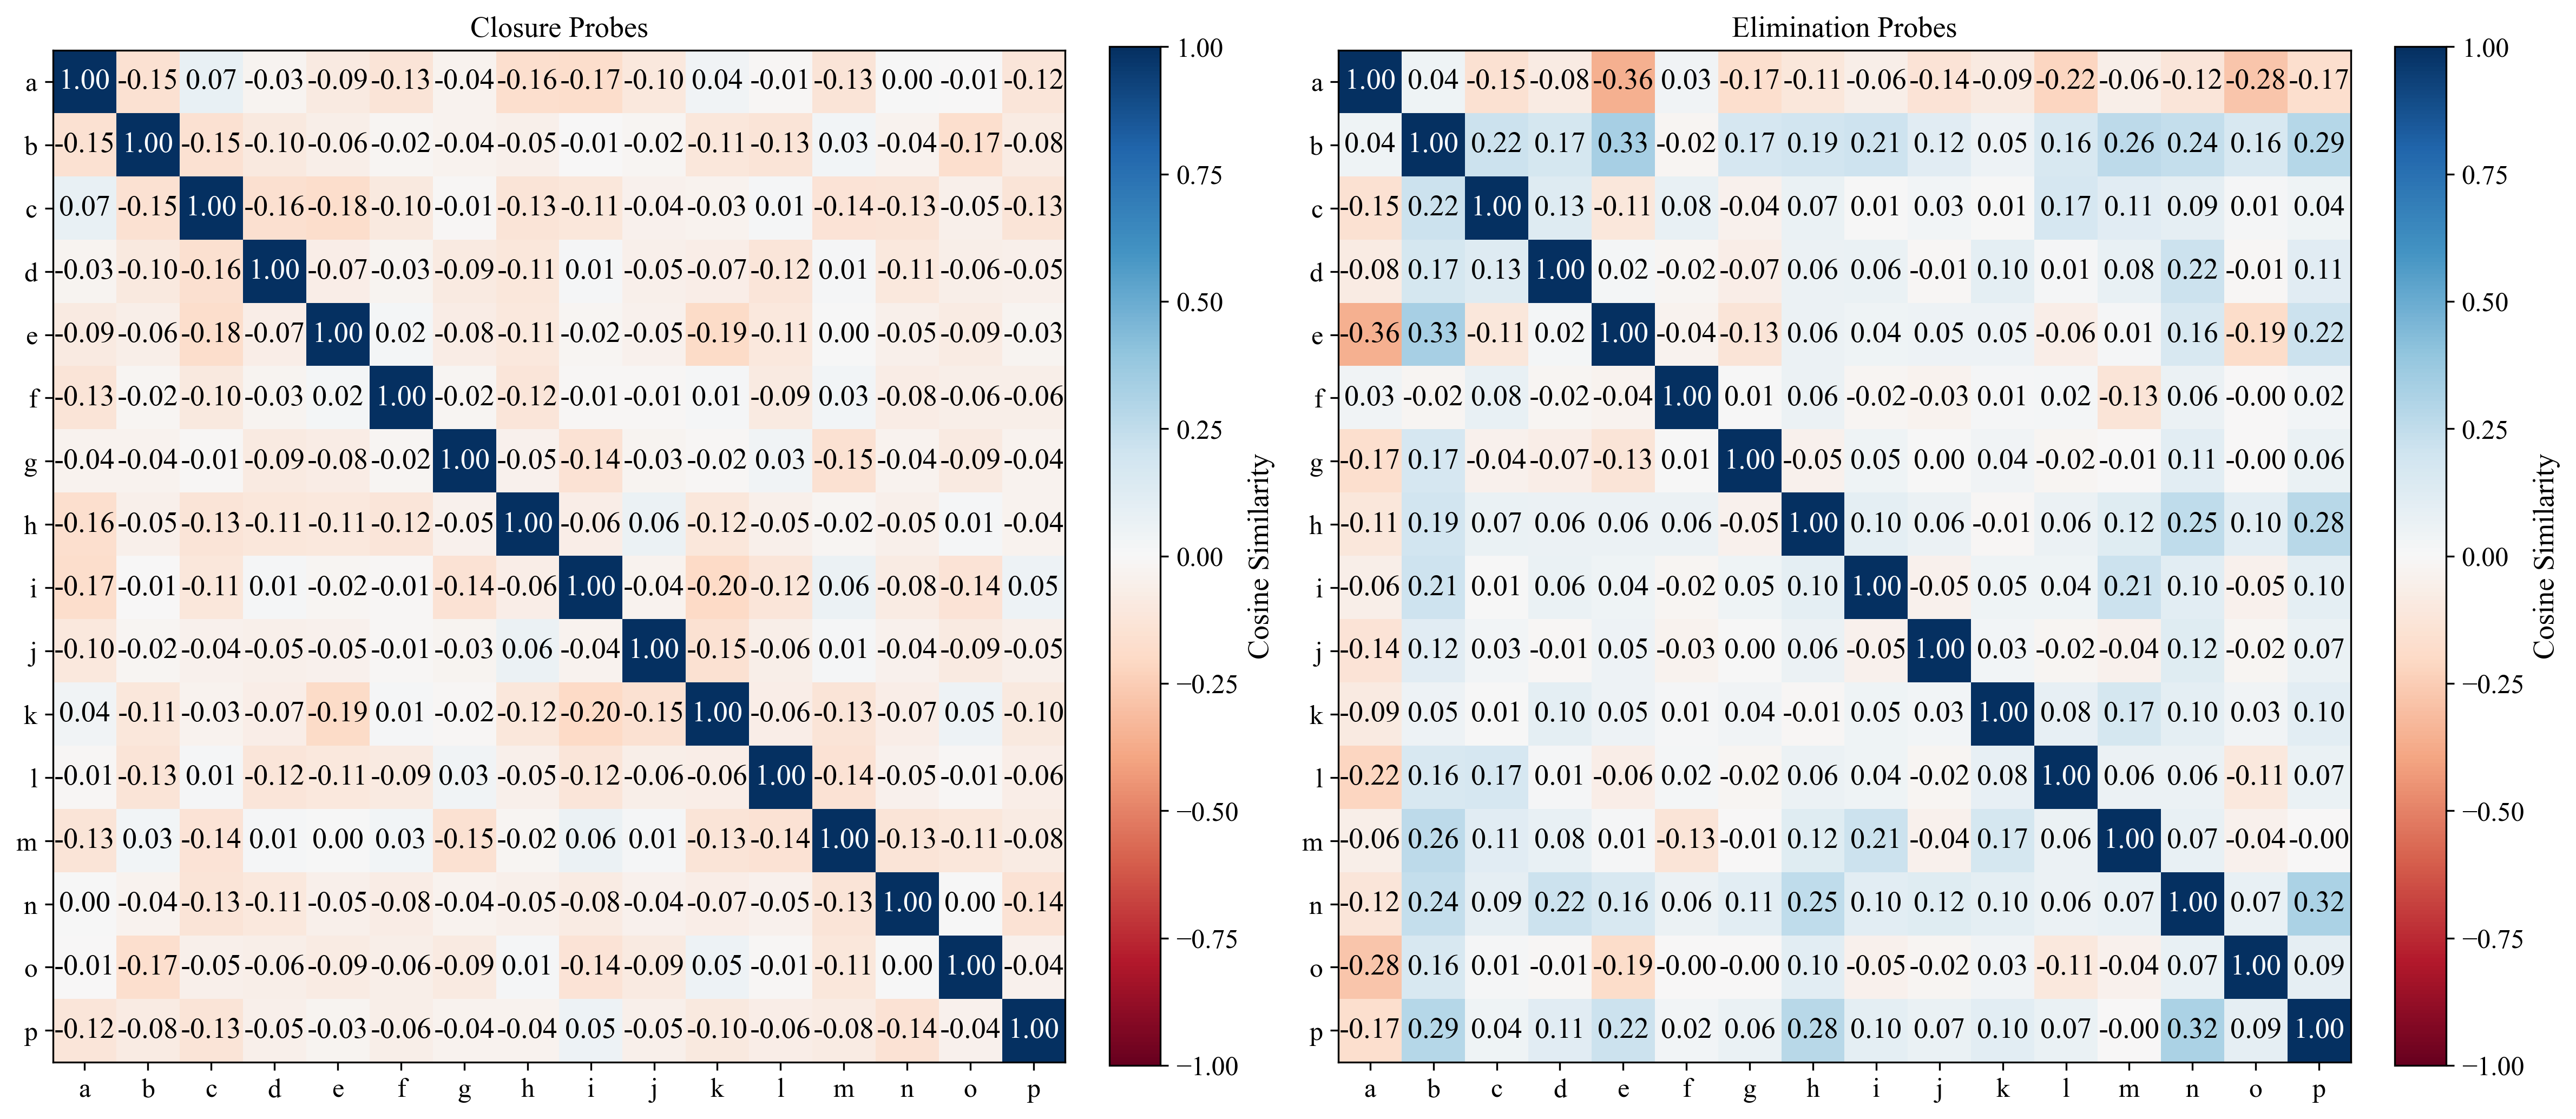

In [ ]:
# =============================================================================
# Generate Publication-Ready Comparison Plots
# =============================================================================

print("\n" + "="*60)
print("GENERATING PUBLICATION-READY PLOTS")
print("="*60)

# 1. Probe generalization comparison
print("\n1. Plotting probe generalization comparison...")
fig_gen = plot_probe_generalization_comparison(
    closure_gen_matrix, 
    elimination_gen_matrix, 
    vocab_symbols,
    # save_path='probe_generalization_comparison.pdf'
)
plt.show()

# 2. Probe-unembed alignment comparison (with special tokens)
print("2. Plotting probe-unembed alignment comparison...")
fig_unembed = plot_probe_unembed_alignment_comparison(
    closure_probe_results,
    elimination_probe_results,
    model,
    task,
    vocab_symbols,
    closure_subspace,
    elimination_subspace,
    # save_path='probe_unembed_alignment_comparison.pdf'
)
plt.show()

# 3. Probe direction similarities comparison
print("3. Plotting probe direction similarities comparison...")
fig_sim = plot_probe_similarities_comparison(
    closure_probe_results,
    elimination_probe_results,
    vocab_symbols,
    # save_path='probe_cosine_similarities_comparison.pdf'
)
plt.show()